In [2]:
# Step 1: Environment setup
# Google Drive is mounted and required libraries are imported.

from google.colab import drive
import pandas as pd
import numpy as np

# Google Drive is mounted to access the project data directory
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Step 2: Data loading and initial inspection
# The verified-review corpus produced in the data collection stage
# is read from Google Drive and its structure is inspected.

# The verified reviews dataset is loaded from the project data directory
df = pd.read_csv('/content/drive/MyDrive/MSc-Project/data/reviews_verified.csv')

# The shape, column names, and data types are displayed for verification
print("Dataset shape:", df.shape)
print("\nColumns and data types:")
print(df.dtypes)

# Missing values are counted for each column
print("\nMissing values per column:")
print(df.isnull().sum())

# A small sample of rows is displayed for visual inspection
df.head(3)

Dataset shape: (70852, 12)

Columns and data types:
rating               float64
title                 object
text                  object
images                object
asin                  object
parent_asin           object
user_id               object
timestamp              int64
helpful_vote           int64
verified_purchase       bool
review_length          int64
word_count             int64
dtype: object

Missing values per column:
rating               0
title                8
text                 8
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
review_length        0
word_count           0
dtype: int64


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,review_length,word_count
0,1.0,Received Used & scratched item! Purchased new!,Livid. Once again received an obviously used ...,[],B007WQ9YNO,B09XWYG6X1,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1677373409298,1,True,160,28
1,5.0,Excellent for moving & storage & floods!,I purchased these for multiple reasons. The ma...,[],B09H2VJW6K,B0BXDLF8TW,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1672043410846,0,True,2709,546
2,2.0,Lid very loose- needs a gasket imo. Small base.,[[VIDEOID:c87e962bc893a948856b0f1b285ce6cc]] I...,[{'small_image_url': 'https://m.media-amazon.c...,B07RL297VR,B09G2PW8ZG,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1653447296788,0,True,1616,319


In [5]:
# Step 3: Removal of missing values and duplicates
# Rows with missing review text are removed, as text is the primary
# input to the sentiment analysis pipeline. Duplicate reviews are
# identified and removed to prevent repeated observations from
# biasing the analysis.

# Rows with missing review text are dropped
before = len(df)
df = df.dropna(subset=['text']).copy()
print("Rows removed due to missing text:", before - len(df))

# Missing titles are replaced with an empty string, as the title is secondary
df['title'] = df['title'].fillna('')

# Duplicate reviews are identified using user, product, and text together
before = len(df)
df = df.drop_duplicates(subset=['user_id', 'asin', 'text']).copy()
print("Duplicate rows removed:", before - len(df))

print("Remaining reviews:", len(df))

Rows removed due to missing text: 8
Duplicate rows removed: 51
Remaining reviews: 70793


In [6]:
# Step 4: Minimal regex-based text cleaning
# A deliberately minimal cleaning strategy is applied. Embedded media
# tags, HTML fragments, URLs, and redundant whitespace are removed,
# while punctuation, capitalisation, and emoticons are retained, as
# these carry sentiment signal used by VADER and the transformer models.

import re

def clean_text(text):
    # Embedded Amazon media tags such as [[VIDEOID:...]] are removed
    text = re.sub(r'\[\[.*?\]\]', ' ', str(text))
    # HTML tags and entities are removed
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'&[a-z]+;', ' ', text)
    # URLs are removed
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    # Redundant whitespace is collapsed into single spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# The cleaning function is applied to the review text and title
df['clean_text'] = df['text'].apply(clean_text)
df['clean_title'] = df['title'].apply(clean_text)

# Reviews left empty after cleaning are removed
before = len(df)
df = df[df['clean_text'].str.len() > 0].copy()
print("Rows removed after cleaning (empty text):", before - len(df))

# A before-and-after example is displayed for verification
print("\nOriginal:", df['text'].iloc[2][:200])
print("\nCleaned :", df['clean_text'].iloc[2][:200])

Rows removed after cleaning (empty text): 38

Original: [[VIDEOID:c87e962bc893a948856b0f1b285ce6cc]] I wanted to love this bc I previously bought a matching turquoise teapot, but the loose lid (defective or design flaw? Idk) on the cups is driving me batty

Cleaned : I wanted to love this bc I previously bought a matching turquoise teapot, but the loose lid (defective or design flaw? Idk) on the cups is driving me batty. I’m disabled so my gait is not great to beg


In [7]:
# Step 5: Saving the cleaned dataset and preprocessing summary
# The cleaned corpus is saved to Google Drive for use in the NLP
# pipeline. A summary table of the preprocessing steps is generated
# programmatically and exported for inclusion in the dissertation.

import os

output_data_path = '/content/drive/MyDrive/MSc-Project/data/reviews_cleaned.csv'
output_dir = '/content/drive/MyDrive/MSc-Project/outputs'
os.makedirs(output_dir, exist_ok=True)

# The cleaned dataset is saved to the project data directory
df.to_csv(output_data_path, index=False)
print("Cleaned dataset saved:", output_data_path)
print("Final shape:", df.shape)

# A summary table of the preprocessing pipeline is constructed
summary = pd.DataFrame({
    'Preprocessing step': [
        'Initial verified-review corpus',
        'Removal of missing review text',
        'Removal of duplicate reviews',
        'Regex cleaning (media tags, HTML, URLs, whitespace)',
        'Final cleaned corpus'
    ],
    'Reviews remaining': [70852, 70844, len(df) + 38, len(df), len(df)]
})

# The summary table is exported to CSV for the dissertation
summary_path = os.path.join(output_dir, 'preprocessing_summary_table.csv')
summary.to_csv(summary_path, index=False)
print("\nSummary table saved:", summary_path)
summary

Cleaned dataset saved: /content/drive/MyDrive/MSc-Project/data/reviews_cleaned.csv
Final shape: (70755, 14)

Summary table saved: /content/drive/MyDrive/MSc-Project/outputs/preprocessing_summary_table.csv


,Preprocessing step,Reviews remaining
0,Initial verified-review corpus,70852
1,Removal of missing review text,70844
2,Removal of duplicate reviews,70793
3,"Regex cleaning (media tags, HTML, URLs, whites...",70755
4,Final cleaned corpus,70755


count    70755.000000
mean        40.654738
std         56.535559
min          1.000000
25%         10.000000
50%         24.000000
75%         49.000000
max       1612.000000
Name: clean_word_count, dtype: float64


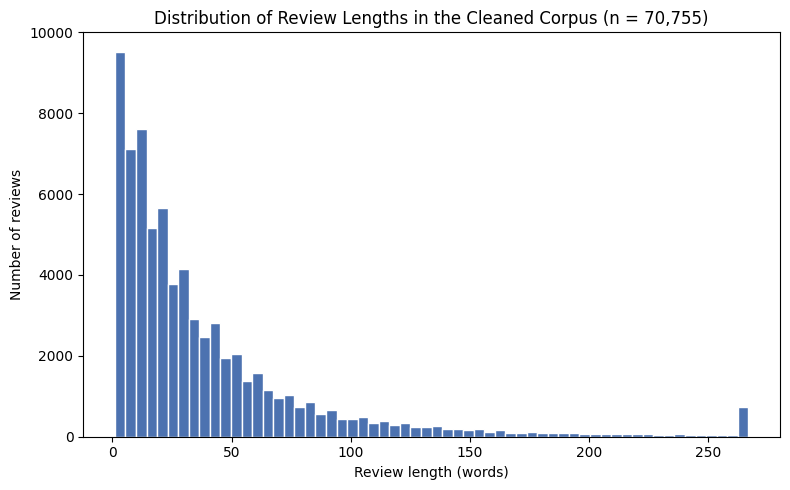

Figure saved: /content/drive/MyDrive/MSc-Project/outputs/review_length_distribution.png


In [8]:
# Step 6: Review length distribution of the cleaned corpus
# The distribution of review word counts is visualised to characterise
# the corpus before sentiment analysis. The figure is saved at 300 dpi
# for direct inclusion in the dissertation.

import matplotlib.pyplot as plt

# The word count is recalculated on the cleaned text
df['clean_word_count'] = df['clean_text'].str.split().str.len()

# Descriptive statistics of the cleaned review lengths are displayed
print(df['clean_word_count'].describe())

# The distribution is plotted, capped at the 99th percentile for readability
cap = df['clean_word_count'].quantile(0.99)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['clean_word_count'].clip(upper=cap), bins=60,
        color='#4C72B0', edgecolor='white')
ax.set_xlabel('Review length (words)')
ax.set_ylabel('Number of reviews')
ax.set_title('Distribution of Review Lengths in the Cleaned Corpus (n = 70,755)')
plt.tight_layout()

# The figure is saved at 300 dpi to the project outputs directory
fig_path = '/content/drive/MyDrive/MSc-Project/outputs/review_length_distribution.png'
plt.savefig(fig_path, dpi=300)
plt.show()
print("Figure saved:", fig_path)